In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,PowerTransformer,OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
from tensorflow.keras.regularizers import L1,L2
from kerastuner.tuners import RandomSearch
from tensorflow import keras
import tensorflow as tf



C:\Users\Admin\AppData\Local\Temp\ipykernel_18424\2234066125.py:14: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [2]:
df= pd.read_csv(r"train.csv")
df_test= pd.read_csv(r"test.csv")
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [4]:
df.shape

(630000, 21)

# DATA PREPROCESSING


In [5]:
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()
#THERE IS NO OUTLIERS 

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [8]:
df.info()
#TYPES ARE TRUE

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [9]:
df.drop(["id","Water_Source","Irrigation_Type"], axis=1,inplace=True)
sub = df_test[['id']]
df_test.drop(["id","Water_Source","Irrigation_Type"], axis=1,inplace=True)

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,7.37,No,93.19,South,Low


In [10]:
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [11]:
df['Irrigation_Need'] = df['Irrigation_Need'].map({'Low': 0, 'Medium': 1 , 'High':2})
df['Irrigation_Need']


0         0
1         0
2         0
3         1
4         0
         ..
629995    1
629996    1
629997    2
629998    0
629999    0
Name: Irrigation_Need, Length: 630000, dtype: int64

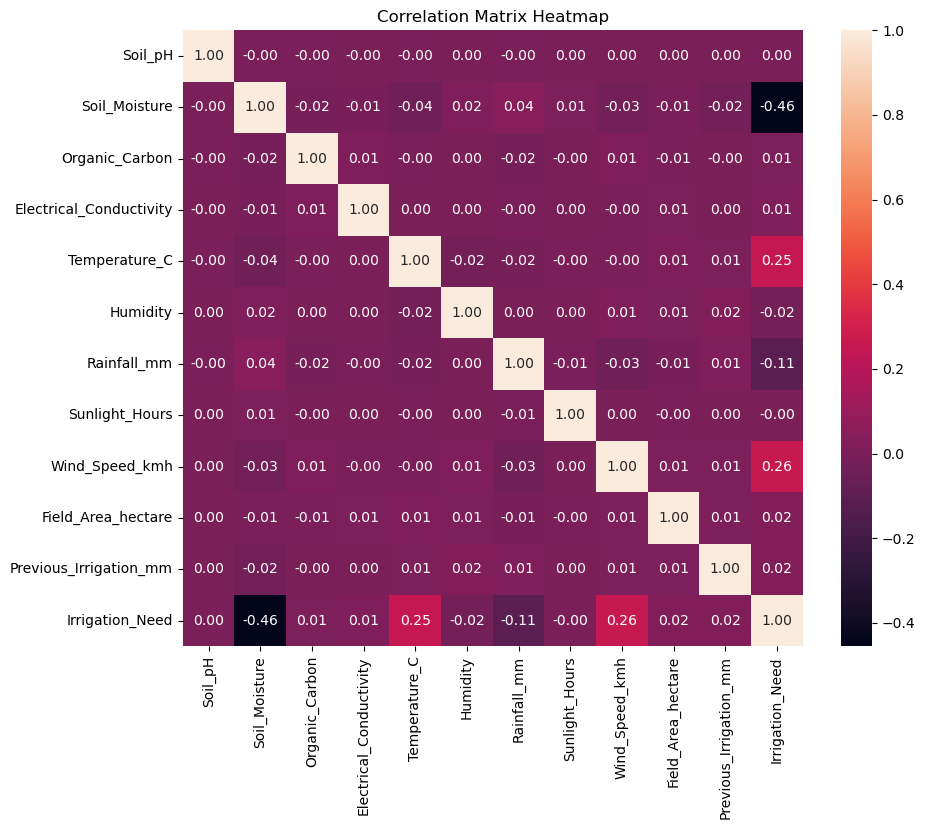

In [12]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()
# there is no linear relationship between features

In [13]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Field_Area_hectare', 'Mulching_Used',
       'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

# feature engineering


In [14]:
def feature_engineering(df):
 df["water_stress"] = df["Temperature_C"] / (df["Soil_Moisture"] + 1)
 df["evaporation"] = df["Temperature_C"] * df["Sunlight_Hours"]
 df['evapotranspiration_proxy'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
 df["rain_balance"] = df["Rainfall_mm"] - df["Previous_Irrigation_mm"]
 df["moisture_temp"] = df["Soil_Moisture"] * df["Temperature_C"]
 df["humidity_temp"] = df["Humidity"] * df["Temperature_C"]
 df['humidity_per_moisture'] = df['Humidity'] / (df['Soil_Moisture'] + 1)
 df['temp_per_conductivity'] = df['Temperature_C'] / (df['Electrical_Conductivity'] + 0.1)
 df['temp_humidity_ratio'] = df['Temperature_C'] / (df['Humidity'] + 1)
 df['moisture_gap'] = df['Soil_Moisture'] - df['Humidity']
 df['rain_effect'] = df['Rainfall_mm'] / (df['Soil_Moisture'] + 1)
 df['effective_water_input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
 df['moisture_deficit'] = df['Soil_Moisture'] - df['Previous_Irrigation_mm']
 df['temp_moisture_ratio'] = df['Temperature_C'] / (df['Soil_Moisture'] + 1)

 return df

df = feature_engineering(df)
df_test = feature_engineering(df_test)

In [15]:
# def feature_engineering(df):
#     # Existing features
#     df["water_stress"] = df["Temperature_C"] / (df["Soil_Moisture"] + 1)

#     df["evaporation"] = df["Temperature_C"] * df["Sunlight_Hours"]
#     df["rain_balance"] = df["Rainfall_mm"] - df["Previous_Irrigation_mm"]

#     #df["moisture_temp"] = df["Soil_Moisture"] * df["Temperature_C"]###

#     #df["humidity_temp"] = df["Humidity"] * df["Temperature_C"]######
#     df["irrigation_per_area"] = df["Previous_Irrigation_mm"] / df["Field_Area_hectare"]
#     df["rain_per_area"] = df["Rainfall_mm"] / df["Field_Area_hectare"]
#     df['humidity_per_moisture'] = df['Humidity'] / (df['Soil_Moisture'] + 1)  
#     df['temp_per_conductivity'] = df['Temperature_C'] / (df['Electrical_Conductivity'] + 0.1)
#     df['temp_humidity_ratio'] = df['Temperature_C'] / (df['Humidity'] + 1)  
    
#     df['moisture_gap'] = df['Soil_Moisture'] - df['Humidity']
#     df['rain_effect'] = df['Rainfall_mm'] / (df['Soil_Moisture'] + 1)

    
#     df['temp_squared'] = df['Temperature_C'] ** 2

#     df['moisture_log'] = np.log(df['Soil_Moisture'] + 1)

  
#     df['evapotranspiration_proxy'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)

#     df['thermal_stress_index'] = (df['Temperature_C'] - 25) ** 2  # assuming 25°C optimal

   
#     df['moisture_change'] = df['Soil_Moisture'].diff().fillna(0)

#     df['temp_change'] = df['Temperature_C'].diff().fillna(0)

   
#     df['rain_irrigation_ratio'] = (df['Rainfall_mm'] + 1) / (df['Previous_Irrigation_mm'] + 1)

#     df['moisture_deficit'] = df['Soil_Moisture'] - df['Previous_Irrigation_mm']

#     df['cwsi'] = (df['Temperature_C'] - df['Humidity']) / (df['Temperature_C'] + 1)

#     df['moisture_deficit_ratio'] = (df['Soil_Moisture'] + 1) / (df['Rainfall_mm'] + df['Previous_Irrigation_mm'] + 1)

#     df['effective_water_input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']

#     df['water_balance_area'] = df['effective_water_input'] / (df['Field_Area_hectare'] + 0.1)

#     df['heat_humidity_index'] = df['Temperature_C'] * (df['Humidity'] / 100)

#     df['temp_wind_evap'] = df['Temperature_C'] * df['Wind_Speed_kmh']

#     df['moisture_trend'] = df['Soil_Moisture'].rolling(3).mean().fillna(df['Soil_Moisture'])

#     df['rain_7d'] = df['Rainfall_mm'].rolling(7).sum().fillna(0)

#     df['temp_moisture_ratio'] = df['Temperature_C'] / (df['Soil_Moisture'] + 1)
    
#     df['temp_moisture_product'] = df['Temperature_C'] * df['Soil_Moisture']

#     df['water_stress_index'] = (df['Temperature_C'] ** 2) / (df['Soil_Moisture'] + 1)




#     df['moisture_deficit_heat'] = (df['Soil_Moisture'] - df['Previous_Irrigation_mm']) / (df['Temperature_C'] + 1)

#     df['temp_moisture_squared'] = (df['Temperature_C'] * df['Soil_Moisture']) ** 2
#     df['log_temp_moisture'] = np.log(df['Temperature_C'] + 1) * np.log(df['Soil_Moisture'] + 1)

#     return df


# df = feature_engineering(df)
# df_test = feature_engineering(df_test)


In [16]:
# #to transform numerical values to categorical

# def categorize_ph(ph):
#     if ph < 6.5:
#         return 'acidic'
#     elif 6.5 <= ph <= 7.5: 
#         return 'neutral'
#     else:
#         return 'alkaline'

# df['Soil_pH'] = df['Soil_pH'].apply(categorize_ph)
# df_test['Soil_pH'] = df_test['Soil_pH'].apply(categorize_ph)
# df['Soil_pH'].head(10)


In [17]:
df.dtypes

Soil_Type                    object
Soil_pH                     float64
Soil_Moisture               float64
Organic_Carbon              float64
Electrical_Conductivity     float64
Temperature_C               float64
Humidity                    float64
Rainfall_mm                 float64
Sunlight_Hours              float64
Wind_Speed_kmh              float64
Crop_Type                    object
Crop_Growth_Stage            object
Season                       object
Field_Area_hectare          float64
Mulching_Used                object
Previous_Irrigation_mm      float64
Region                       object
Irrigation_Need               int64
water_stress                float64
evaporation                 float64
evapotranspiration_proxy    float64
rain_balance                float64
moisture_temp               float64
humidity_temp               float64
humidity_per_moisture       float64
temp_per_conductivity       float64
temp_humidity_ratio         float64
moisture_gap                

In [18]:
#from a research we get these values

# def categorize_electrical(ec_value):
#     if ec_value < 0.5:   #low salts
#         return "Low"
#     elif 0.5 <= ec_value <= 2.0:   #medium salts
#         return "Medium"
#     else:         #high salts
#         return "High"
    
# df['Electrical_Conductivity'] = df['Electrical_Conductivity'].apply(categorize_electrical)
# df_test['Electrical_Conductivity'] = df_test['Electrical_Conductivity'].apply(categorize_electrical)
# df['Electrical_Conductivity'].head(10)



In [19]:

df["total_water"]=df['Rainfall_mm']+df['Previous_Irrigation_mm']
df_test["total_water"]=df_test['Rainfall_mm']+df_test['Previous_Irrigation_mm']
df.head()


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,humidity_temp,humidity_per_moisture,temp_per_conductivity,temp_humidity_ratio,moisture_gap,rain_effect,effective_water_input,moisture_deficit,temp_moisture_ratio,total_water
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,759.6561,1.507147,4.765079,0.290835,-18.03,21.619714,838.15,-79.58,0.446992,838.15
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,1555.3512,1.177920,10.914286,0.332849,-11.25,17.109182,1032.82,9.45,0.397848,1032.82
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,2487.1734,3.212121,9.204778,0.289316,-64.51,76.687565,2312.08,-82.67,0.939394,2312.08
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,820.1124,4.299581,13.731959,0.212882,-48.25,94.785615,1411.18,-40.53,0.930168,1411.18
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,1842.2442,1.514965,19.075472,0.219520,-31.97,25.576987,1631.39,-34.05,0.336215,1631.39


In [20]:

# df=df.drop(['Rainfall_mm' , 'Previous_Irrigation_mm'] , axis=1)
# df_test=df_test.drop(['Rainfall_mm' , 'Previous_Irrigation_mm'] , axis=1)


In [21]:
df.head()


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,humidity_temp,humidity_per_moisture,temp_per_conductivity,temp_humidity_ratio,moisture_gap,rain_effect,effective_water_input,moisture_deficit,temp_moisture_ratio,total_water
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,759.6561,1.507147,4.765079,0.290835,-18.03,21.619714,838.15,-79.58,0.446992,838.15
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,1555.3512,1.177920,10.914286,0.332849,-11.25,17.109182,1032.82,9.45,0.397848,1032.82
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,2487.1734,3.212121,9.204778,0.289316,-64.51,76.687565,2312.08,-82.67,0.939394,2312.08
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,820.1124,4.299581,13.731959,0.212882,-48.25,94.785615,1411.18,-40.53,0.930168,1411.18
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,1842.2442,1.514965,19.075472,0.219520,-31.97,25.576987,1631.39,-34.05,0.336215,1631.39


In [22]:
x=df.drop('Irrigation_Need' , axis=1)
y=df['Irrigation_Need']

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.9 , random_state=42)

In [24]:
#train Encoding 
cat_col = list(x_train.select_dtypes(include=["object", "category"]).columns)
encoder=OrdinalEncoder()
x_train[cat_col]=encoder.fit_transform(x_train[cat_col])
x_test[cat_col]=encoder.transform(x_test[cat_col])


#df_test encoding
df_test[cat_col]=encoder.transform(df_test[cat_col])




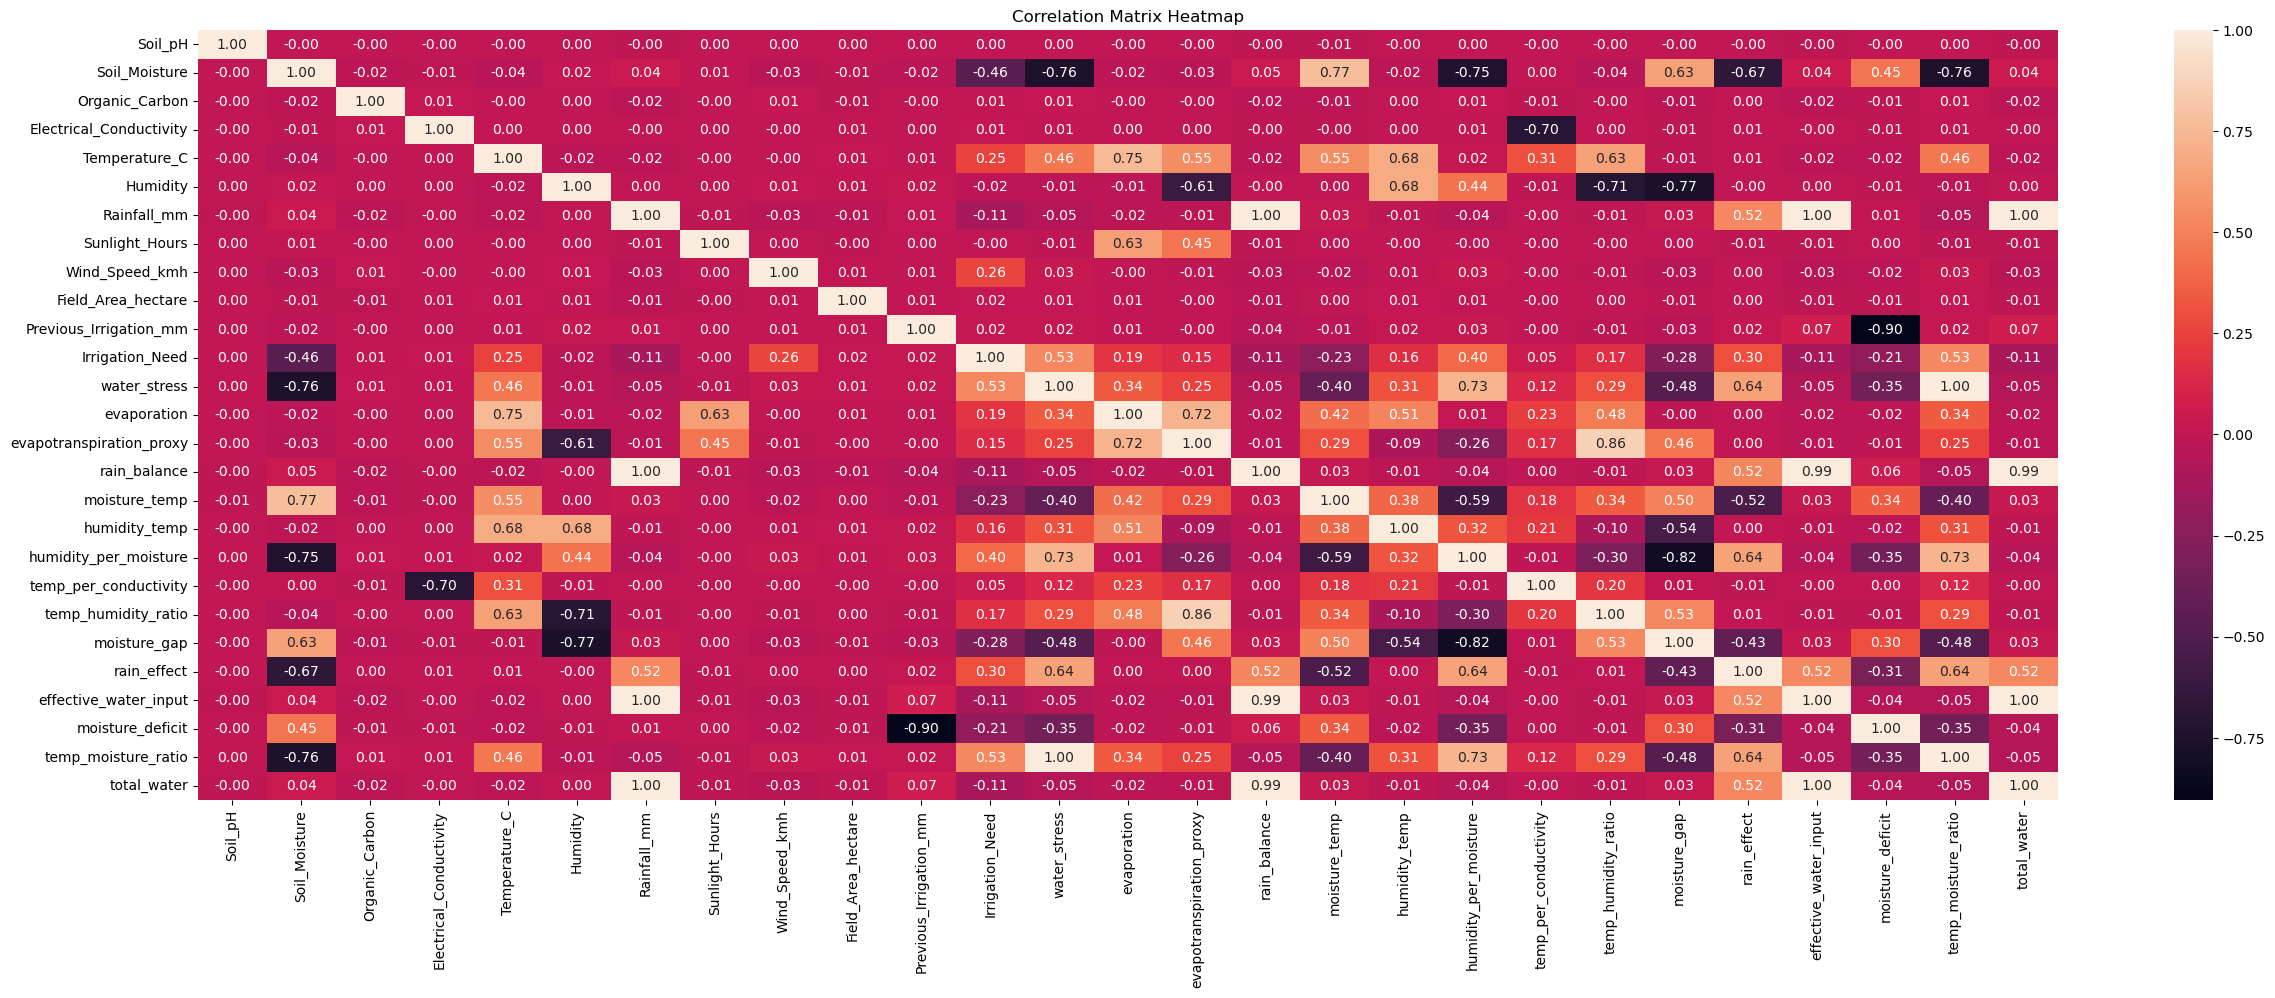

In [25]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(30, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [26]:
#scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


df_test=scaler.transform(df_test)


In [27]:
x_train[10]

array([ 0.46631808, -1.55332433, -0.88615383,  1.46850793,  0.64570817,
       -0.73046373,  0.0120664 , -2.37075617, -0.146109  ,  0.51407354,
       -0.29817277, -1.32668519,  1.24432272,  0.32222452,  1.00465989,
        0.23805651, -1.42983851, -0.07936465, -0.62098574, -0.58905977,
       -2.38208237, -0.95321579, -0.49841392,  0.3344264 , -0.62257863,
       -0.62974876, -0.57971473, -1.27281259, -2.35207616, -0.59158759,
       -0.07936465, -2.35207616])

In [28]:
# def build_model(hp):
#     model=Sequential([
#         Dense(
#             units=hp.Int('units',min_value=128,max_value=256,step=32),
#             activation=hp.Choice('activation','relu'),
#                                  input_shape=(x_train.shape[1],)),
        
#         Dense(
#             units=hp.Int('units',min_value=128,max_value=256,step=16),
#             activation=hp.Choice('activation','relu')
                                 
#         ),
         
#         Dense(
#             units=hp.Int('units',min_value=64,max_value=128,step=16),
#             activation=hp.Choice('activation','relu')
                                 
#         ),
         
#         Dense(
#             units=hp.Int('units',min_value=16,max_value=32,step=16),
#             activation=hp.Choice('activation','relu')
#         ),
#         Dense(3, activation='softmax')
#     ])

#     model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate',[0.01,0.001])), loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
    
#     return model

In [29]:
model=keras.Sequential()
model.add(keras.layers.Dense(265,activation='relu',input_shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(265,activation='relu'))
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dense(32,activation='relu'))
model.add(keras.layers.Dense(32,activation='relu'))
model.add(keras.layers.Dense(16,activation='relu'))

model.add(keras.layers.Dense(3,activation='softmax'))
print(model.summary())

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 265)            │         8,745 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 265)            │        70,490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,598 (650.77 KB)

 Trainable params: 166,598 (650.77 KB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
model.compile(loss='sparse_categorical_crossentropy',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

In [31]:
early_stopping=EarlyStopping(patience=5 , monitor='val_loss')

In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights))

print(class_weights_dict)

{np.int64(0): np.float64(0.5674346549456883), np.int64(1): np.float64(0.8789757374792464), np.int64(2): np.float64(10.000529128525319)}


In [33]:
history=model.fit(x_train,y_train,epochs=50,batch_size=64,validation_split=0.1,class_weight=class_weights_dict , callbacks=[early_stopping])



Epoch 1/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9237 - loss: 0.2194 - val_accuracy: 0.9602 - val_loss: 0.1241
Epoch 2/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9611 - loss: 0.1471 - val_accuracy: 0.9673 - val_loss: 0.1160
Epoch 3/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9675 - loss: 0.1338 - val_accuracy: 0.9719 - val_loss: 0.1065
Epoch 4/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9694 - loss: 0.1314 - val_accuracy: 0.9728 - val_loss: 0.1088
Epoch 5/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9697 - loss: 0.1330 - val_accuracy: 0.9704 - val_loss: 0.1221
Epoch 6/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9722 - loss: 0.1246 - val_accuracy: 0.9726 - val_loss: 0.1054
Epoch 7/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9732 - loss: 0.1197 - val_accuracy: 0.9732 - val_loss: 0.1061
Epoch 8/50
7974/7974 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9734 - loss: 0

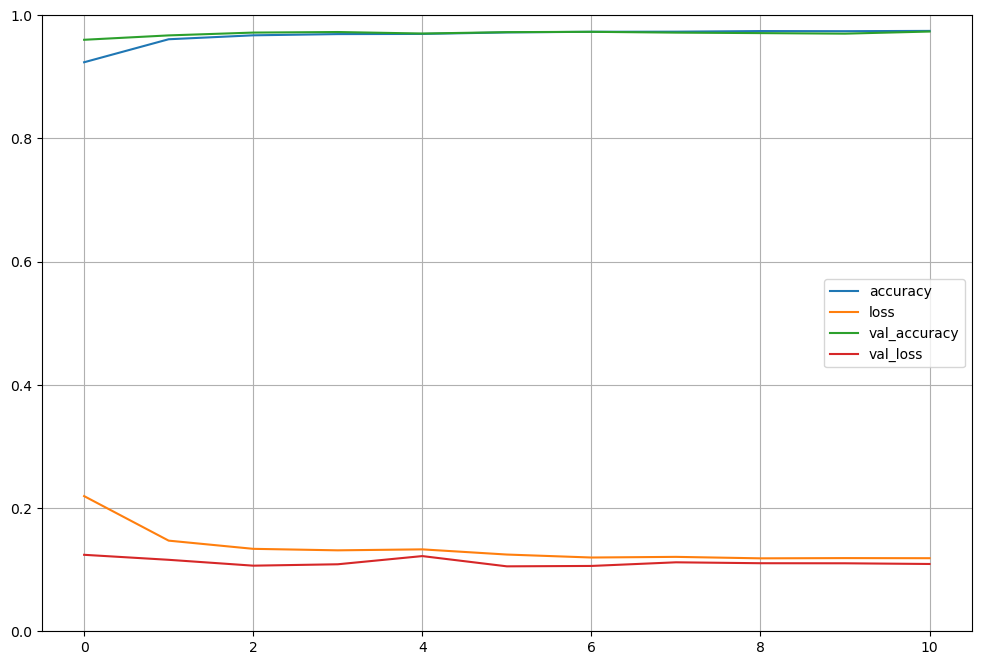

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.9744 - loss: 0.1056
Loss : 0.10562443733215332
accuracy 0.9743809700012207


In [34]:
pd.DataFrame(history.history).plot(figsize=(12,8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()



###*---------------Evaluate the model----------------
model_evalute=model.evaluate(x_test,y_test)
print('Loss :',model_evalute[0])
print('accuracy',model_evalute[1])

In [35]:
import pandas as pd
import numpy as np


y_pred = model.predict(df_test)


y_pred_classes = np.argmax(y_pred, axis=1)

label_map_reverse = {0:'Low', 1:'Medium' , 2:'High'}
sub['Irrigation_Need'] = y_pred_classes
sub['Irrigation_Need'] = sub['Irrigation_Need'].map(label_map_reverse)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 6s 761us/step


In [36]:
sub

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


In [37]:
sub.to_csv("sub.csv", index=False)

In [38]:
import pickle

# Save model
model.save("model.h5")

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save encoder (if used)
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)